In [1]:
import numpy as np
import numpy.linalg as nplg
import numpy.random as npra
from Finite_Optimal_User import dis_reward
from Myopic_User import *
from Three_State_Whittle_Index_user import *

In [2]:
from matplotlib.font_manager import FontManager
fm = FontManager()
mat_fonts = set(f.name for f in fm.ttflist)
#print(mat_fonts)
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']

In [2]:
arm_num = 7
state_num = 3 
active_num = 1
reward_set =np.array([0, 2, 3])
reward_set = np.array([reward_set for k in range(7)])
time = 6

In [3]:
transition_matrics = np.array([[[0.2, 0.5, 0.3],[0.4, 0.5, 0.1], [0.4, 0.4, 0.2]],
                              [[0.3, 0.6, 0.1], [0.2, 0.4, 0.4], [0.1, 0.4, 0.5]],
                              [[0.3, 0.5, 0.2], [0.4, 0.2, 0.4], [0.1, 0.2, 0.7]],
                              [[0.1, 0.5, 0.4], [0.6, 0.2, 0.2], [0.3, 0.2, 0.5]],
                              [[0.2, 0.5, 0.3], [0.6, 0.3, 0.1], [0.5, 0.3, 0.2]],
                              [[0.4, 0.2, 0.4], [0.6, 0.2, 0.2], [0.3, 0.1, 0.6]],
                              [[0.3, 0.5, 0.2], [0.6, 0.3, 0.1], [0.3, 0.4, 0.3]]])

In [4]:
def gen_P():
    P = npra.rand(3,3)
    P = P/P.sum(axis = 1).reshape((3, 1))
    return P
def gen_w(N):
    w = npra.rand(N, 3)
    w = w/w.sum(axis = 1).reshape(N, 1)
    return w
def gen_B(N):
    B = npra.rand(N,3)
    while (B[:, 2] < B[:, 1]).any():
        B[:, 2] = npra.rand(N)
    B[:, 0] = 0
    return B

In [928]:
for k in range(7):
    transition_matrics[k] = gen_P()

In [929]:
transition_matrics

array([[[3.35156341e-01, 4.58424671e-01, 2.06418988e-01],
        [7.83309035e-03, 4.17596686e-01, 5.74570224e-01],
        [2.19275889e-01, 1.31637786e-01, 6.49086325e-01]],

       [[2.57135906e-02, 6.93014842e-01, 2.81271568e-01],
        [1.78845151e-01, 4.85704250e-01, 3.35450599e-01],
        [6.90430126e-01, 1.96788573e-01, 1.12781301e-01]],

       [[3.92223765e-01, 3.37337206e-01, 2.70439029e-01],
        [8.74969403e-01, 8.05515430e-02, 4.44790539e-02],
        [3.60980927e-01, 3.64599454e-01, 2.74419618e-01]],

       [[6.21381627e-01, 3.51444609e-01, 2.71737637e-02],
        [4.46520166e-01, 4.88105983e-01, 6.53738512e-02],
        [4.72543167e-02, 6.04517371e-01, 3.48228312e-01]],

       [[2.35569888e-01, 3.51662080e-01, 4.12768032e-01],
        [6.53327249e-01, 1.56363428e-01, 1.90309323e-01],
        [2.57141031e-01, 2.54467717e-01, 4.88391251e-01]],

       [[5.71865748e-01, 5.94407185e-04, 4.27539845e-01],
        [3.17266634e-01, 4.07635669e-01, 2.75097697e-01],
    

In [930]:
J, A = nplg.eig(transition_matrics)
A_inv = nplg.inv(A)
print(J)

[[ 1.        +0.j          0.20091968+0.24872689j  0.20091968-0.24872689j]
 [-0.18790043+0.16281371j -0.18790043-0.16281371j  1.        +0.j        ]
 [ 1.        +0.j         -0.23051585+0.j         -0.02228922+0.j        ]
 [ 1.        +0.j          0.36364525+0.j          0.09407067+0.j        ]
 [ 1.        +0.j         -0.2597662 +0.j          0.14009076+0.j        ]
 [ 1.        +0.j         -0.06251746+0.j          0.38343169+0.j        ]
 [ 1.        +0.j         -0.28527199+0.j         -0.0087032 +0.j        ]]


In [931]:
initial_dist = np.array([[0.6, 0.3, 0.1],
                        [0.4, 0.4, 0.2],
                        [0.5, 0.2, 0.3],
                        [0.5, 0.2, 0.3],
                        [0.5, 0.2, 0.3],
                        [0.6, 0.2, 0.2],
                        [0.5, 0.3, 0.2]])


In [932]:
reward_set = gen_B(7)*3
reward_set

array([[0.        , 1.11967066, 1.71046127],
       [0.        , 2.28477654, 2.46707696],
       [0.        , 2.72484085, 2.76160331],
       [0.        , 0.94322928, 1.90790339],
       [0.        , 2.92205848, 2.94575449],
       [0.        , 0.32020389, 1.53660502],
       [0.        , 1.40747859, 2.60850811]])

In [933]:
initial_dist = gen_w(7)
rew = initial_dist.reshape((7, 1, 3))@reward_set.reshape((7, 3, 1))
while (rew > 1.5).any():
    initial_dist = gen_w(7)
    rew = initial_dist.reshape((7, 1, 3))@reward_set.reshape((7, 3, 1)) 
initial_dist

array([[0.39411914, 0.27495237, 0.3309285 ],
       [0.42511954, 0.36321511, 0.21166535],
       [0.49581797, 0.17618286, 0.32799917],
       [0.68370513, 0.00748808, 0.30880679],
       [0.58613721, 0.05117524, 0.36268755],
       [0.2274605 , 0.61469431, 0.15784519],
       [0.48720772, 0.03176843, 0.48102385]])

In [934]:
myopic_100 = np.zeros((100, 6))
myopic_100000 = np.zeros((100000, 6))
myopic_10000 = np.zeros((10000, 6))
whittle_100 = np.zeros((100, 6))
whittle_100000 = np.zeros((100000, 6))
whittle_10000 = np.zeros((10000, 6))
optimal_100 = np.zeros((100, 6))
optimal_1000 = np.zeros((1000, 6))
optimal_10000 = np.zeros((10000, 6))

In [935]:
for n in range(10000):
    user = Myopic_User(arm_num, state_num, initial_dist, transition_matrics, active_num, reward_set, 6)
    user.User_process()
    myopic_100000[n] = user.AR

In [936]:
myopic = (myopic_100000.cumsum(axis = 1)/np.array(range(1,7))).sum(axis = 0)/(n + 1)
myopic

array([1.41239747, 1.7936428 , 1.8735956 , 1.92671542, 1.95013913,
       1.9686396 ])

In [937]:
J, A = nplg.eig(transition_matrics)
A_inv = nplg.inv(A)
all_type = [np.array([False, False, False, False, False, False, False,]),
            np.array([False, False, False, False, False, False, False]),
            np.array([False, False, False, False, False, False, False])]
for k in range(7):
    if (J[k, 0] - J[k, 1]).imag != 0:
        all_type[2][k] = True
    elif ((A[k]@np.diag(J[k])@A_inv[k] - transition_matrics[k])**2).sum() > 1e-10:
        all_type[1][k] = True
    else:
        all_type[0][k] = True

In [938]:
for n in range(1000):
    user = Whittle_Index_Three_State(arm_num, state_num, initial_dist, transition_matrics, active_num, reward_set, time)
    user.User_process(0.9999, [True, A, J, A_inv, all_type])
    whittle_100000[n] = user.AR
    if n%10000 == 0:
        print(n)

0


In [939]:
whittle = (whittle_100000.cumsum(axis = 1)/np.array(range(1,7))).sum(axis = 0)/(n + 1)
whittle

array([1.35245921, 1.74795853, 1.85918605, 1.9115252 , 1.95052307,
       1.97033563])

In [940]:
y = np.zeros(6)
for t in range(1, time + 1):
    a, b = dis_reward(initial_dist, reward_set, arm_num, transition_matrics, state_num, 1, 1, t)
    y[t - 1] = b/t
    print(b/t)

1.3858738353275868
1.7805440378131805
1.864213691709118
1.9168516332518957
1.9456223715712828
1.9648789864699847


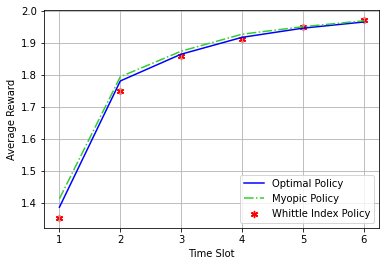

In [941]:
plt.plot(range(1, 7), y, label='Optimal Policy', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index Policy', c='red', marker=(6,2,0))
plt.plot(range(1, 7), myopic, label='Myopic Policy', c='limegreen', linestyle='-.')

plt.grid()
plt.xlabel('Time Slot')
plt.ylabel('Average Reward')
plt.legend()

In [942]:
(whittle - myopic).sum()/(myopic.sum()*6)
(y - myopic).sum()/(myopic.sum()*6)


-0.0010243274251924349

In [943]:
(y - myopic).sum()/(6)

-0.011190910301179432

/usr/local/lib/python3.9/site-packages/matplotlib/textpath.py:74: RuntimeWarning: Glyph 26102 missing from current font.
  font.set_text(s, 0.0, flags=LOAD_NO_HINTING)
/usr/local/lib/python3.9/site-packages/matplotlib/textpath.py:74: RuntimeWarning: Glyph 21051 missing from current font.
  font.set_text(s, 0.0, flags=LOAD_NO_HINTING)
/usr/local/lib/python3.9/site-packages/matplotlib/textpath.py:74: RuntimeWarning: Glyph 23454 missing from current font.
  font.set_text(s, 0.0, flags=LOAD_NO_HINTING)
/usr/local/lib/python3.9/site-packages/matplotlib/textpath.py:74: RuntimeWarning: Glyph 38469 missing from current font.
  font.set_text(s, 0.0, flags=LOAD_NO_HINTING)
/usr/local/lib/python3.9/site-packages/matplotlib/textpath.py:74: RuntimeWarning: Glyph 25910 missing from current font.
  font.set_text(s, 0.0, flags=LOAD_NO_HINTING)
/usr/local/lib/python3.9/site-packages/matplotlib/textpath.py:74: RuntimeWarning: Glyph 30410 missing from current font.
  font.set_text(s, 0.0, flags=LOAD_NO_H

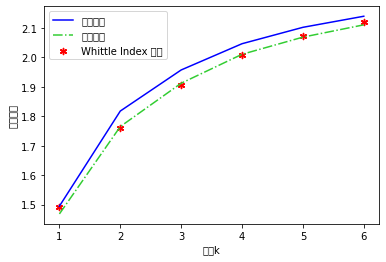

In [910]:
plt.plot(range(1, 7), y, label='最优策略', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index 策略', c='red', marker=(6,2,0))
plt.plot(range(1, 7), myopic, label='短视策略', c='limegreen', linestyle='-.')

plt.xlabel('时刻k')
plt.ylabel('实际收益')
plt.legend()


In [911]:
(whittle - myopic).sum()/6
(y - myopic).sum()/6

0.037158051024614926

In [32]:
myopic, whittle, y

(array([1.39170186, 1.57979514, 1.61959284, 1.66344601, 1.69207102,
        1.70954324]),
 array([1.34194525, 1.63784278, 1.68021315, 1.71133337, 1.73374262,
        1.74874625]),
 array([1.38746713, 1.63524776, 1.68363852, 1.71546359, 1.7365047 ,
        1.75178491]))

In [33]:
transition_matrics
initial_dist
#reward_set

array([[0.40530772, 0.41489083, 0.17980145],
       [0.55068485, 0.32782861, 0.12148654],
       [0.55531456, 0.31498428, 0.12970116],
       [0.49459923, 0.11713724, 0.38826352],
       [0.47391666, 0.23922109, 0.28686225],
       [0.4130367 , 0.38775519, 0.19920811],
       [0.36863708, 0.26248389, 0.36887903]])

In [32]:
reward = np.array([[0.        , 2.14560591, 2.49051198],
       [0.        , 1.57882407, 2.4443405 ],
       [0.        , 0.28588308, 0.64357921],
       [0.        , 2.39062236, 2.85227983],
       [0.        , 0.11133542, 1.41977971],
       [0.        , 0.32356284, 0.75464923],
       [0.        , 0.49093289, 0.79702367]])
initial_dist = np.array([[0.40530772, 0.41489083, 0.17980145],
       [0.55068485, 0.32782861, 0.12148654],
       [0.55531456, 0.31498428, 0.12970116],
       [0.49459923, 0.11713724, 0.38826352],
       [0.47391666, 0.23922109, 0.28686225],
       [0.4130367 , 0.38775519, 0.19920811],
       [0.36863708, 0.26248389, 0.36887903]])
transition_matrics = np.array([[[0.48810832, 0.25776698, 0.2541247 ],
        [0.01153224, 0.79048947, 0.1979783 ],
        [0.68118517, 0.20761701, 0.11119782]],

       [[0.35363718, 0.31111394, 0.33524887],
        [0.27852809, 0.02685346, 0.69461845],
        [0.50240524, 0.34061562, 0.15697913]],

       [[0.34244191, 0.03553621, 0.62202187],
        [0.45067775, 0.21868514, 0.33063711],
        [0.47049742, 0.07326167, 0.45624091]],

       [[0.30403609, 0.63872958, 0.05723433],
        [0.45719306, 0.37996151, 0.16284543],
        [0.26163595, 0.3567756 , 0.38158845]],

       [[0.40383511, 0.2822885 , 0.31387639],
        [0.62104316, 0.1057811 , 0.27317574],
        [0.20361715, 0.65675182, 0.13963103]],

       [[0.5860492 , 0.02382524, 0.39012555],
        [0.45456905, 0.0273101 , 0.51812086],
        [0.36492302, 0.46448779, 0.1705892 ]],

       [[0.61188959, 0.33474526, 0.05336515],
        [0.33254181, 0.48605061, 0.18140757],
        [0.48260942, 0.51312832, 0.00426226]]])

myopic, whittle, y = (np.array([1.39170186, 1.57979514, 1.61959284, 1.66344601, 1.69207102,
        1.70954324]),
 np.array([1.34194525, 1.63784278, 1.68021315, 1.71133337, 1.73374262,
        1.74874625]),
 np.array([1.38746713, 1.63524776, 1.68363852, 1.71546359, 1.7365047 ,
        1.75178491]))


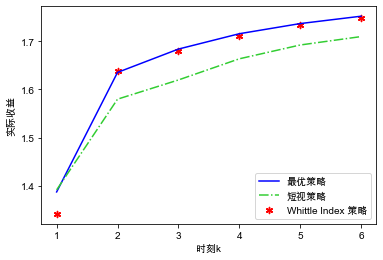

In [925]:
plt.plot(range(1, 7), y, label='最优策略', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index 策略', c='red', marker=(6,2,0))
plt.plot(range(1, 7), myopic, label='短视策略', c='limegreen', linestyle='-.')

plt.xlabel('时刻k')
plt.ylabel('实际收益')
plt.legend()


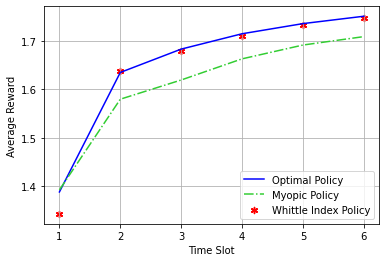

In [33]:
plt.plot(range(1, 7), y, label='Optimal Policy', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index Policy', c='red', marker=(6,2,0))
plt.plot(range(1, 7), myopic, label='Myopic Policy', c='limegreen', linestyle='-.')

plt.grid()
plt.xlabel('Time Slot')
plt.ylabel('Average Reward')
plt.legend()

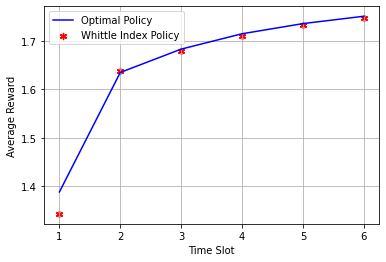

In [34]:
plt.plot(range(1, 7), y, label='Optimal Policy', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index Policy', c='red', marker=(6,2,0))
#plt.plot(range(1, 7), myopic, label='Myopic Policy', c='limegreen', linestyle='-.')

plt.grid()
plt.xlabel('Time Slot')
plt.ylabel('Average Reward')
plt.legend()

In [927]:
(whittle - myopic).sum()/6

0.03294555166666665

In [928]:
np.round(transition_matrics, 3)
np.round(initial_dist, 3)
np.round(reward, 3)

array([[0.   , 2.146, 2.491],
       [0.   , 1.579, 2.444],
       [0.   , 0.286, 0.644],
       [0.   , 2.391, 2.852],
       [0.   , 0.111, 1.42 ],
       [0.   , 0.324, 0.755],
       [0.   , 0.491, 0.797]])

In [29]:
reward = np.array([[0.        , 2.42206748, 2.69819648],
       [0.        , 2.74521478, 2.75425419],
       [0.        , 2.91580628, 2.91597828],
       [0.        , 0.05072977, 0.50347744],
       [0.        , 1.50973425, 2.68838885],
       [0.        , 1.62300674, 1.77740053],
       [0.        , 0.89693331, 2.44300813]])

transition_matrics = np.array([[[0.53774449, 0.30513813, 0.15711738],
        [0.5746877 , 0.09719132, 0.32812099],
        [0.34576125, 0.16799788, 0.48624087]],

       [[0.36661433, 0.11424961, 0.51913605],
        [0.79829193, 0.08867959, 0.11302848],
        [0.36704783, 0.3538542 , 0.27909797]],

       [[0.217764  , 0.01466035, 0.76757565],
        [0.84941401, 0.12873254, 0.02185345],
        [0.40475527, 0.15145907, 0.44378567]],

       [[0.42813368, 0.29447104, 0.27739529],
        [0.43118262, 0.02173926, 0.54707812],
        [0.0112245 , 0.51102938, 0.47774612]],

       [[0.31678458, 0.41347602, 0.2697394 ],
        [0.37603937, 0.33337532, 0.2905853 ],
        [0.35095229, 0.20251445, 0.44653326]],

       [[0.31969382, 0.64885586, 0.03145032],
        [0.11133992, 0.0372434 , 0.85141668],
        [0.37733576, 0.36373671, 0.25892753]],

       [[0.04645692, 0.21315374, 0.74038934],
        [0.03071605, 0.42989855, 0.53938539],
        [0.23827418, 0.23815968, 0.52356614]]])



initial_dist = np.array([[0.46223166, 0.41824065, 0.11952769],
       [0.45931842, 0.52822495, 0.01245662],
       [0.5190985 , 0.4131283 , 0.0677732 ],
       [0.11261416, 0.49912065, 0.38826519],
       [0.55492081, 0.40045517, 0.04462402],
       [0.34760475, 0.21203546, 0.44035979],
       [0.48324016, 0.04985429, 0.46690555]])


myopic, whittle, y = (np.array([1.48321239, 1.61556396, 1.71692847, 1.76229019, 1.7935594 ,
        1.81306458]),
 np.array([1.4072381 , 1.7148944 , 1.78869357, 1.81614759, 1.83695862,
        1.84771958]),
 np.array([1.48439966, 1.71352638, 1.78626613, 1.81780464, 1.83785533,
        1.85127021]))

/usr/local/lib/python3.9/site-packages/matplotlib/textpath.py:74: RuntimeWarning: Glyph 26102 missing from current font.
  font.set_text(s, 0.0, flags=LOAD_NO_HINTING)
/usr/local/lib/python3.9/site-packages/matplotlib/textpath.py:74: RuntimeWarning: Glyph 21051 missing from current font.
  font.set_text(s, 0.0, flags=LOAD_NO_HINTING)
/usr/local/lib/python3.9/site-packages/matplotlib/textpath.py:74: RuntimeWarning: Glyph 23454 missing from current font.
  font.set_text(s, 0.0, flags=LOAD_NO_HINTING)
/usr/local/lib/python3.9/site-packages/matplotlib/textpath.py:74: RuntimeWarning: Glyph 38469 missing from current font.
  font.set_text(s, 0.0, flags=LOAD_NO_HINTING)
/usr/local/lib/python3.9/site-packages/matplotlib/textpath.py:74: RuntimeWarning: Glyph 25910 missing from current font.
  font.set_text(s, 0.0, flags=LOAD_NO_HINTING)
/usr/local/lib/python3.9/site-packages/matplotlib/textpath.py:74: RuntimeWarning: Glyph 30410 missing from current font.
  font.set_text(s, 0.0, flags=LOAD_NO_H

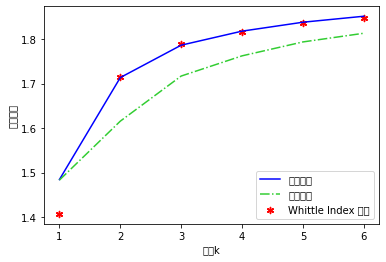

In [4]:
plt.plot(range(1, 7), y, label='最优策略', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index 策略', c='red', marker=(6,2,0))
plt.plot(range(1, 7), myopic, label='短视策略', c='limegreen', linestyle='-.')

plt.xlabel('时刻k')
plt.ylabel('实际收益')
plt.legend()

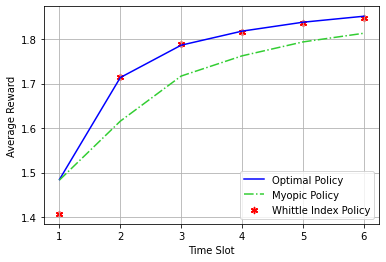

In [30]:
plt.plot(range(1, 7), y, label='Optimal Policy', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index Policy', c='red', marker=(6,2,0))
plt.plot(range(1, 7), myopic, label='Myopic Policy', c='limegreen', linestyle='-.')

plt.grid()
plt.xlabel('Time Slot')
plt.ylabel('Average Reward')
plt.legend()

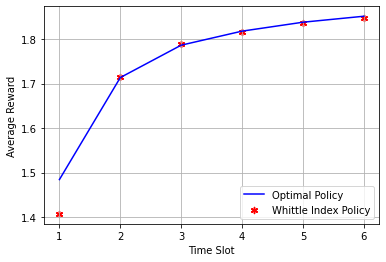

In [31]:
plt.plot(range(1, 7), y, label='Optimal Policy', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index Policy', c='red', marker=(6,2,0))
#plt.plot(range(1, 7), myopic, label='Myopic Policy', c='limegreen', linestyle='-.')

plt.grid()
plt.xlabel('Time Slot')
plt.ylabel('Average Reward')
plt.legend()

In [922]:
np.round(transition_matrics, 3)
np.round(initial_dist, 3)
np.round(reward, 3)

array([[0.   , 2.422, 2.698],
       [0.   , 2.745, 2.754],
       [0.   , 2.916, 2.916],
       [0.   , 0.051, 0.503],
       [0.   , 1.51 , 2.688],
       [0.   , 1.623, 1.777],
       [0.   , 0.897, 2.443]])

In [923]:
(whittle-myopic).sum()/6

0.03783881166666662

array([[0.        , 0.09102392, 2.19371674],
       [0.        , 2.01446669, 2.68794727],
       [0.        , 0.20557358, 2.67853847],
       [0.        , 2.64856997, 2.92317081],
       [0.        , 1.21583091, 1.22066493],
       [0.        , 1.48440898, 1.71740779],
       [0.        , 1.71322854, 2.90889765]])

array([[[0.22884072, 0.52821142, 0.24294786],
        [0.51514431, 0.04766852, 0.43718717],
        [0.40382896, 0.3236109 , 0.27256014]],

       [[0.24638017, 0.53882243, 0.2147974 ],
        [0.38148924, 0.43114515, 0.18736562],
        [0.15754376, 0.51337897, 0.32907727]],

       [[0.01380416, 0.54449999, 0.44169585],
        [0.35642219, 0.58891997, 0.05465785],
        [0.31342844, 0.37806385, 0.30850771]],

       [[0.17289392, 0.45450305, 0.37260304],
        [0.29690322, 0.45547942, 0.24761735],
        [0.61885442, 0.31771422, 0.06343136]],

       [[0.08842715, 0.7410019 , 0.17057096],
        [0.45762959, 0.02848782, 0.51388258],
        [0.34653189, 0.31745898, 0.33600913]],

       [[0.30573549, 0.49520609, 0.19905842],
        [0.94750552, 0.02521431, 0.02728016],
        [0.38024956, 0.42431061, 0.19543983]],

       [[0.37178933, 0.23200803, 0.39620265],
        [0.1781637 , 0.47934319, 0.34249311],
        [0.45009799, 0.21278881, 0.3371132 ]]])

array([[0.21816484, 0.1046792 , 0.67715596],
       [0.51402817, 0.41304937, 0.07292246],
       [0.07350306, 0.73047605, 0.19602089],
       [0.49119586, 0.12572206, 0.38308208],
       [0.13230801, 0.40717806, 0.46051394],
       [0.48532996, 0.38112173, 0.13354831],
       [0.59459524, 0.39910963, 0.00629513]])

myopic, whittle, y
(array([1.49654346, 1.63079402, 1.74386253, 1.79666238, 1.82914737,
        1.85068403]),
 array([1.45428191, 1.72873149, 1.80913479, 1.84520687, 1.86778835,
        1.88319226]),
 array([1.49501667, 1.72797133, 1.80607765, 1.8436334 , 1.86671744,
        1.8818963 ]))


array([[0.50892755, 0.12711089, 0.36396156],
       [0.4416065 , 0.47122764, 0.08716586],
       [0.45500636, 0.14939515, 0.39559848],
       [0.15239796, 0.47617945, 0.37142259],
       [0.45019294, 0.38456154, 0.16524551],
       [0.52214884, 0.40388786, 0.07396331],
       [0.33745324, 0.14023447, 0.52231229]])

array([[0.        , 2.22832312, 2.87914472],
       [0.        , 0.7732903 , 2.50052977],
       [0.        , 0.1115726 , 0.99701042],
       [0.        , 0.98398641, 2.34149887],
       [0.        , 1.89785444, 2.66614836],
       [0.        , 0.55034722, 2.8072282 ],
       [0.        , 0.6551694 , 1.84578341]])


array([[[0.85541143, 0.09760244, 0.04698612],
        [0.23900007, 0.24553317, 0.51546677],
        [0.35572528, 0.08469756, 0.55957715]],

       [[0.14870712, 0.48902439, 0.36226849],
        [0.24992332, 0.22172288, 0.5283538 ],
        [0.64455525, 0.20524661, 0.15019814]],

       [[0.38988673, 0.43821139, 0.17190188],
        [0.34604044, 0.08042303, 0.57353654],
        [0.44668428, 0.33491945, 0.21839627]],

       [[0.37304309, 0.25907749, 0.36787942],
        [0.20853805, 0.34868822, 0.44277373],
        [0.0090393 , 0.51138292, 0.47957778]],

       [[0.67444252, 0.21891445, 0.10664303],
        [0.28538796, 0.47380541, 0.24080663],
        [0.10643054, 0.29453423, 0.59903523]],

       [[0.54985443, 0.1915548 , 0.25859077],
        [0.37162218, 0.21998464, 0.40839318],
        [0.23231251, 0.29033983, 0.47734767]],

       [[0.10960598, 0.44319426, 0.44719976],
        [0.71194423, 0.13944702, 0.14860875],
        [0.42223394, 0.31310406, 0.264662 

myopic, whittle, y
(array([1.33883565, 1.40019337, 1.4238938 , 1.44385585, 1.45959121,
        1.48292259]),
 array([1.33540904, 1.44392502, 1.51542343, 1.54902837, 1.56403572,
        1.57409346]),
 array([1.33823968, 1.48638209, 1.52278444, 1.55328051, 1.56952825,
        1.57893561]))

In [4]:
reward_set = [0,2,3]
transition_matrics = np.array([[[0.51393363, 0.32131945, 0.16474692],
                                [0.12278214, 0.1588537 , 0.71836416],
                                [0.42028016, 0.19548771, 0.38423213]],

                                [[0.37188072, 0.54326717, 0.08485211],
                                [0.1029638 , 0.63296836, 0.26406784],
                                [0.41706787, 0.30066313, 0.282269  ]],

                                [[0.40542659, 0.12865755, 0.46591585],
                                [0.41320904, 0.3277946 , 0.25899635],
                                [0.32687902, 0.50226893, 0.17085205]],

                                [[0.46133429, 0.27222459, 0.26644112],
                                [0.55542817, 0.43139331, 0.01317852],
                                [0.05797401, 0.68904234, 0.25298365]],

                                [[0.33910131, 0.42723286, 0.23366583],
                                [0.1609922 , 0.46854001, 0.3704678 ],
                                [0.26496859, 0.2960904 , 0.43894101]],

                                [[0.07130874, 0.55589318, 0.37279808],
                                [0.15818948, 0.30846332, 0.5333472 ],
                                [0.41226483, 0.45888471, 0.12885046]],

                                [[0.4271665 , 0.32354619, 0.24928732],
                                [0.47842393, 0.35594085, 0.16563522],
                                [0.32568328, 0.49035809, 0.18395863]]])
initial_dist = np.array([[0.27919425, 0.61839383, 0.10241192],
                          [0.68757133, 0.02395572, 0.28847295],
                          [0.48936163, 0.40846561, 0.10217276],
                          [0.55429178, 0.06029031, 0.38541792],
                          [0.313476  , 0.29660697, 0.38991703],
                          [0.33199808, 0.30471399, 0.36328793],
                          [0.23404061, 0.72205029, 0.0439091 ]])


myopic, whittle, y = (np.array([1.76237   , 1.89277   , 1.93289667, 1.9650825 , 1.984846  ,
        1.99769333]),
 np.array([1.70179 , 1.92301 , 1.98257 , 2.001255, 2.0158  , 2.02405 ]),
 np.array([1.76296503, 1.92175961, 1.9832628 , 2.00439271, 2.01870532,
        2.02843174]))

In [3]:
np.round(initial_dist, 3)

array([[0.279, 0.618, 0.102],
       [0.688, 0.024, 0.288],
       [0.489, 0.408, 0.102],
       [0.554, 0.06 , 0.385],
       [0.313, 0.297, 0.39 ],
       [0.332, 0.305, 0.363],
       [0.234, 0.722, 0.044]])

In [4]:
np.round(transition_matrics,3)

array([[[0.514, 0.321, 0.165],
        [0.123, 0.159, 0.718],
        [0.42 , 0.195, 0.384]],

       [[0.372, 0.543, 0.085],
        [0.103, 0.633, 0.264],
        [0.417, 0.301, 0.282]],

       [[0.405, 0.129, 0.466],
        [0.413, 0.328, 0.259],
        [0.327, 0.502, 0.171]],

       [[0.461, 0.272, 0.266],
        [0.555, 0.431, 0.013],
        [0.058, 0.689, 0.253]],

       [[0.339, 0.427, 0.234],
        [0.161, 0.469, 0.37 ],
        [0.265, 0.296, 0.439]],

       [[0.071, 0.556, 0.373],
        [0.158, 0.308, 0.533],
        [0.412, 0.459, 0.129]],

       [[0.427, 0.324, 0.249],
        [0.478, 0.356, 0.166],
        [0.326, 0.49 , 0.184]]])

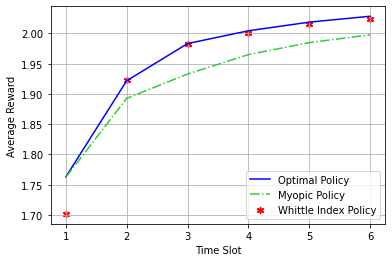

In [9]:
plt.plot(range(1, 7), y, label='Optimal Policy', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index Policy', c='red', marker=(6,2,0))
plt.plot(range(1, 7), myopic, label='Myopic Policy', c='limegreen', linestyle='-.')

plt.grid()
plt.xlabel('Time Slot')
plt.ylabel('Average Reward')
plt.legend()

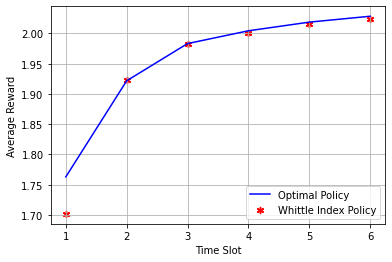

In [10]:
fig, ax = plt.subplots()
plt.plot(range(1, 7), y, label='Optimal Policy', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index Policy', c='red', marker=(6,2,0))
#plt.plot(range(1, 7), myopic, label='Myopic Policy', c='limegreen', linestyle='-.')

plt.grid()
plt.xlabel('Time Slot')
plt.ylabel('Average Reward')
plt.legend()

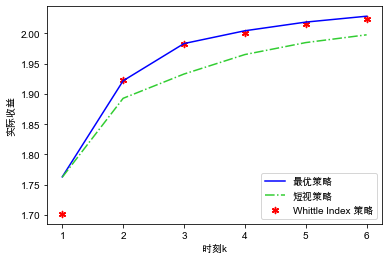

In [358]:
plt.plot(range(1, 7), y, label='最优策略', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index 策略', c='red', marker=(6,2,0))
plt.plot(range(1, 7), myopic, label='短视策略', c='limegreen', linestyle='-.')

plt.xlabel('时刻k')
plt.ylabel('实际收益')
plt.legend()

In [332]:
(whittle - myopic).sum()/6

0.01880274999999994

In [11]:
reward = np.array([[0,2,3],[0,2,3],[0,2,3],[0,2,3],[0,2,3],[0,2,3],[0,2,3]])
transition_matrics = np.array([[[0.51924009, 0.44476686, 0.03599305],
        [0.18768101, 0.2921306 , 0.5201884 ],
        [0.04295743, 0.2915779 , 0.66546467]],

       [[0.19267076, 0.53435088, 0.27297836],
        [0.27530008, 0.48547173, 0.23922819],
        [0.23354326, 0.69427575, 0.07218099]],

       [[0.25057217, 0.27367001, 0.47575782],
        [0.6005015 , 0.24155168, 0.15794682],
        [0.27155075, 0.198801  , 0.52964825]],

       [[0.72024981, 0.2034329 , 0.07631729],
        [0.20105599, 0.62144105, 0.17750296],
        [0.44367025, 0.318915  , 0.23741475]],

       [[0.16094868, 0.44547293, 0.39357839],
        [0.24931171, 0.39393107, 0.35675721],
        [0.16401366, 0.36260157, 0.47338477]],

       [[0.08019329, 0.27888382, 0.64092289],
        [0.02651163, 0.78091359, 0.19257478],
        [0.41770272, 0.26497122, 0.31732606]],

       [[0.13045535, 0.53564835, 0.3338963 ],
        [0.37670411, 0.25358561, 0.36971028],
        [0.33364092, 0.12026902, 0.54609006]]])

initial_dist = np.array([[0.35416032, 0.16414869, 0.48169099],
       [0.42644729, 0.18775039, 0.38580232],
       [0.33255912, 0.49813778, 0.1693031 ],
       [0.45655525, 0.284924  , 0.25852075],
       [0.35144269, 0.42416396, 0.22439335],
       [0.10150386, 0.89261463, 0.00588152],
       [0.36724308, 0.27624752, 0.3565094 ]])
       
myopic, whittle, y=(np.array([1.8033    , 1.98769   , 2.03583667, 2.075195  , 2.105534  ,
        2.14387833]),
 np.array([1.7747   , 2.067805 , 2.14672  , 2.1796575, 2.194388 , 2.215455 ]),
 np.array([1.80287382, 2.07039984, 2.14762564, 2.1828688 , 2.20148708,
        2.21794789]))

In [35]:
np.round(transition_matrics, 3)

array([[[0.519, 0.445, 0.036],
        [0.188, 0.292, 0.52 ],
        [0.043, 0.292, 0.665]],

       [[0.193, 0.534, 0.273],
        [0.275, 0.485, 0.239],
        [0.234, 0.694, 0.072]],

       [[0.251, 0.274, 0.476],
        [0.601, 0.242, 0.158],
        [0.272, 0.199, 0.53 ]],

       [[0.72 , 0.203, 0.076],
        [0.201, 0.621, 0.178],
        [0.444, 0.319, 0.237]],

       [[0.161, 0.445, 0.394],
        [0.249, 0.394, 0.357],
        [0.164, 0.363, 0.473]],

       [[0.08 , 0.279, 0.641],
        [0.027, 0.781, 0.193],
        [0.418, 0.265, 0.317]],

       [[0.13 , 0.536, 0.334],
        [0.377, 0.254, 0.37 ],
        [0.334, 0.12 , 0.546]]])

In [36]:
np.round(initial_dist, 3)

array([[0.354, 0.164, 0.482],
       [0.426, 0.188, 0.386],
       [0.333, 0.498, 0.169],
       [0.457, 0.285, 0.259],
       [0.351, 0.424, 0.224],
       [0.102, 0.893, 0.006],
       [0.367, 0.276, 0.357]])

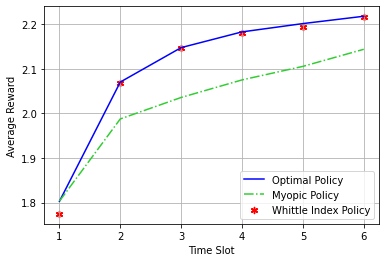

In [12]:
#fig, ax = plt.subplots()
plt.plot(range(1, 7), y, label='Optimal Policy', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index Policy', c='red', marker=(6,2,0))
plt.plot(range(1, 7), myopic, label='Myopic Policy', c='limegreen', linestyle='-.')

plt.grid()
plt.xlabel('Time Slot')
plt.ylabel('Average Reward')
plt.legend()

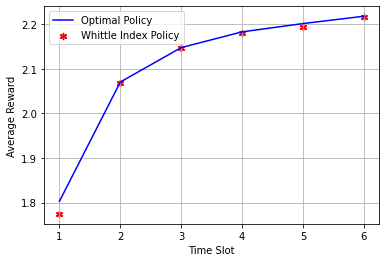

In [13]:
fig, ax = plt.subplots()
plt.plot(range(1, 7), y, label='Optimal Policy', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index Policy', c='red', marker=(6,2,0))
#plt.plot(range(1, 7), myopic, label='Myopic Policy', c='limegreen', linestyle='-.')

plt.grid()
plt.xlabel('Time Slot')
plt.ylabel('Average Reward')
plt.legend()

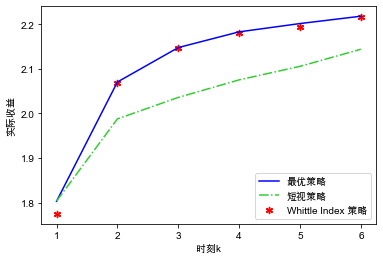

In [362]:
plt.plot(range(1, 7), y, label='最优策略', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index 策略', c='red', marker=(6,2,0))
plt.plot(range(1, 7), myopic, label='短视策略', c='limegreen', linestyle='-.')

plt.xlabel('时刻k')
plt.ylabel('实际收益')
plt.legend()

In [363]:
(whittle - myopic).sum()/6

0.07121524999999995

In [14]:

reward = np.array([[0,2,3],[0,2,3],[0,2,3],[0,2,3],[0,2,3],[0,2,3],[0,2,3]])
transition_matrics = np.array([[[0.34598924, 0.03236481, 0.62164594],
        [0.10529236, 0.52427481, 0.37043282],
        [0.39062175, 0.08450351, 0.52487474]],

       [[0.32861426, 0.54447076, 0.12691498],
        [0.44936084, 0.45732251, 0.09331665],
        [0.43661485, 0.45801621, 0.10536894]],

       [[0.37705541, 0.33188051, 0.29106409],
        [0.2977367 , 0.3433275 , 0.3589358 ],
        [0.57325649, 0.14544664, 0.28129686]],

       [[0.27647747, 0.35813711, 0.36538542],
        [0.32470575, 0.32434734, 0.35094691],
        [0.40245558, 0.38396749, 0.21357693]],

       [[0.14546591, 0.47158612, 0.38294797],
        [0.02813289, 0.08452384, 0.88734327],
        [0.45385948, 0.11811692, 0.4280236 ]],

       [[0.16671365, 0.44192606, 0.39136029],
        [0.21294767, 0.45668987, 0.33036246],
        [0.44239088, 0.55003393, 0.00757519]],

       [[0.26606289, 0.11298066, 0.62095645],
        [0.4432116 , 0.49760949, 0.05917891],
        [0.46422354, 0.42470485, 0.11107161]]])
initial_dist = np.array([[0.39536797, 0.20228699, 0.40234504],
       [0.38729164, 0.38145718, 0.23125118],
       [0.26847672, 0.35909577, 0.37242751],
       [0.31694115, 0.62222199, 0.06083686],
       [0.44966014, 0.07928385, 0.47105601],
       [0.299133  , 0.26794029, 0.43292671],
       [0.55263361, 0.20661552, 0.24075087]])

myopic, whittle, y = (np.array([1.83689  , 1.86784  , 1.93106  , 1.9719975, 1.988818 , 2.00512  ]),
 np.array([1.83862  , 1.885695 , 1.97772  , 2.0032025, 2.012596 , 2.01854  ]),
 np.array([1.83547407, 1.89184886, 1.97914722, 2.00684159, 2.01922276,
        2.03033375]))

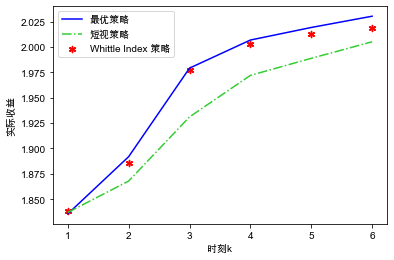

In [39]:
plt.plot(range(1, 7), y, label='最优策略', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index 策略', c='red', marker=(6,2,0))
plt.plot(range(1, 7), myopic, label='短视策略', c='limegreen', linestyle='-.')

plt.xlabel('时刻k')
plt.ylabel('实际收益')
plt.legend()

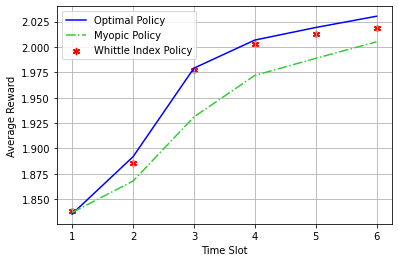

In [15]:
fig, ax = plt.subplots()
plt.plot(range(1, 7), y, label='Optimal Policy', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index Policy', c='red', marker=(6,2,0))
plt.plot(range(1, 7), myopic, label='Myopic Policy', c='limegreen', linestyle='-.')

plt.grid()
plt.xlabel('Time Slot')
plt.ylabel('Average Reward')
plt.legend()

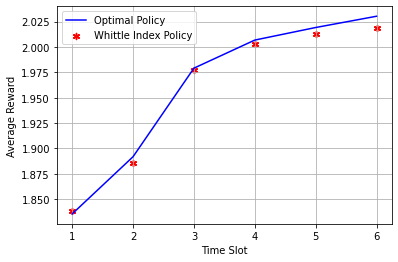

In [16]:
fig, ax = plt.subplots()
plt.plot(range(1, 7), y, label='Optimal Policy', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index Policy', c='red', marker=(6,2,0))
#plt.plot(range(1, 7), myopic, label='Myopic Policy', c='limegreen', linestyle='-.')

plt.grid()
plt.xlabel('Time Slot')
plt.ylabel('Average Reward')
plt.legend()

In [366]:
(whittle - myopic).sum()/6

0.022441333333333275

In [367]:
np.round(transition_matrics, 3)

array([[[0.346, 0.032, 0.622],
        [0.105, 0.524, 0.37 ],
        [0.391, 0.085, 0.525]],

       [[0.329, 0.544, 0.127],
        [0.449, 0.457, 0.093],
        [0.437, 0.458, 0.105]],

       [[0.377, 0.332, 0.291],
        [0.298, 0.343, 0.359],
        [0.573, 0.145, 0.281]],

       [[0.276, 0.358, 0.365],
        [0.325, 0.324, 0.351],
        [0.402, 0.384, 0.214]],

       [[0.145, 0.472, 0.383],
        [0.028, 0.085, 0.887],
        [0.454, 0.118, 0.428]],

       [[0.167, 0.442, 0.391],
        [0.213, 0.457, 0.33 ],
        [0.442, 0.55 , 0.008]],

       [[0.266, 0.113, 0.621],
        [0.443, 0.498, 0.059],
        [0.464, 0.425, 0.111]]])

In [368]:
np.round(initial_dist, 3)

array([[0.395, 0.202, 0.402],
       [0.387, 0.381, 0.231],
       [0.268, 0.359, 0.372],
       [0.317, 0.622, 0.061],
       [0.45 , 0.079, 0.471],
       [0.299, 0.268, 0.433],
       [0.553, 0.207, 0.241]])

In [17]:
reward = np.array([[0,2,3],
                  [0,2,3],
                  [0,2,3],
                  [0,2,3],
                  [0,2,3],
                  [0,2,3],
                  [0,2,3]])
transition_matrics = np.array([[[0.21188973, 0.52910383, 0.25900644],
                                [0.13701699, 0.49965487, 0.36332814],
                                [0.40127147, 0.17790819, 0.42082034]],

                        [[0.38570667, 0.22322517, 0.39106816],
                                [0.62007815, 0.14657206, 0.23334979],
                                [0.71613828, 0.26458124, 0.01928048]],

                        [[0.02023039, 0.67669471, 0.30307491],
                                [0.39590839, 0.43427198, 0.16981963],
                                [0.07552288, 0.61276525, 0.31171187]],

                        [[0.69913365, 0.19280411, 0.10806224],
                                [0.34275168, 0.4931537 , 0.16409462],
                                [0.29741667, 0.56566734, 0.13691598]],

                        [[0.14508409, 0.38084814, 0.47406777],
                                [0.40451631, 0.3520493 , 0.2434344 ],
                                [0.35486436, 0.13647418, 0.50866146]],

                        [[0.40669307, 0.29215576, 0.30115117],
                                [0.04899907, 0.26049763, 0.6905033 ],
                                [0.25955444, 0.30421681, 0.43622875]],

                        [[0.34965946, 0.07701506, 0.57332548],
                                [0.23895812, 0.48100856, 0.28003332],
                                [0.45220525, 0.16431874, 0.38347601]]])
initial_dist = np.array([[0.40744579, 0.27955455, 0.31299965],
                        [0.40147797, 0.34912851, 0.24939352],
                        [0.28707368, 0.35547607, 0.35745025],
                        [0.47650047, 0.28456256, 0.23893697],
                        [0.3302217 , 0.51452717, 0.15525113],
                        [0.34821337, 0.2402349 , 0.41155173],
                        [0.2365122 , 0.44360186, 0.31988594]])
                        
myopic, whittle, y = (np.array([1.85409 , 1.890135, 1.96077 , 1.98874 , 2.008162, 2.02056 ]),
 np.array([1.79055   , 1.948725  , 1.99245   , 2.014845  , 2.0293    ,
        2.03704667]),
 np.array([1.84686154, 1.94559547, 1.98913342, 2.0141353 , 2.02878316,
        2.03805203]))

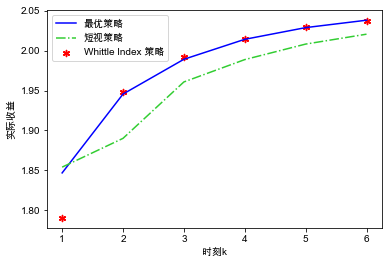

In [42]:
plt.plot(range(1, 7), y, label='最优策略', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index 策略', c='red', marker=(6,2,0))
plt.plot(range(1, 7), myopic, label='短视策略', c='limegreen', linestyle='-.')

plt.xlabel('时刻k')
plt.ylabel('实际收益')
plt.legend()

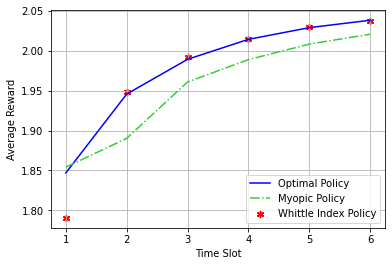

In [19]:
fig, ax = plt.subplots()
plt.plot(range(1, 7), y, label='Optimal Policy', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index Policy', c='red', marker=(6,2,0))
plt.plot(range(1, 7), myopic, label='Myopic Policy', c='limegreen', linestyle='-.')

plt.grid()
plt.xlabel('Time Slot')
plt.ylabel('Average Reward')
plt.legend()

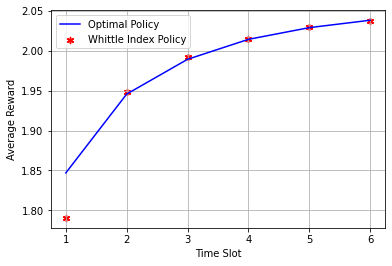

In [20]:
fig, ax = plt.subplots()
plt.plot(range(1, 7), y, label='Optimal Policy', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index Policy', c='red', marker=(6,2,0))
#plt.plot(range(1, 7), myopic, label='Myopic Policy', c='limegreen', linestyle='-.')

plt.grid()
plt.xlabel('Time Slot')
plt.ylabel('Average Reward')
plt.legend()

In [371]:
(whittle - myopic).sum()/6

0.015076611666666776

In [372]:
np.round(transition_matrics, 3)

array([[[0.212, 0.529, 0.259],
        [0.137, 0.5  , 0.363],
        [0.401, 0.178, 0.421]],

       [[0.386, 0.223, 0.391],
        [0.62 , 0.147, 0.233],
        [0.716, 0.265, 0.019]],

       [[0.02 , 0.677, 0.303],
        [0.396, 0.434, 0.17 ],
        [0.076, 0.613, 0.312]],

       [[0.699, 0.193, 0.108],
        [0.343, 0.493, 0.164],
        [0.297, 0.566, 0.137]],

       [[0.145, 0.381, 0.474],
        [0.405, 0.352, 0.243],
        [0.355, 0.136, 0.509]],

       [[0.407, 0.292, 0.301],
        [0.049, 0.26 , 0.691],
        [0.26 , 0.304, 0.436]],

       [[0.35 , 0.077, 0.573],
        [0.239, 0.481, 0.28 ],
        [0.452, 0.164, 0.383]]])

In [373]:
np.round(initial_dist, 3)

array([[0.407, 0.28 , 0.313],
       [0.401, 0.349, 0.249],
       [0.287, 0.355, 0.357],
       [0.477, 0.285, 0.239],
       [0.33 , 0.515, 0.155],
       [0.348, 0.24 , 0.412],
       [0.237, 0.444, 0.32 ]])

In [21]:
reward = np.array([[0.        , 1.00399163, 2.18619847],
                        [0.        , 1.15456088, 2.760683  ],
                        [0.        , 0.43677442, 0.78178706],
                        [0.        , 0.56759874, 0.6191129 ],
                        [0.        , 2.44821117, 2.63023554],
                        [0.        , 1.3269632 , 1.9454126 ],
                        [0.        , 1.85819098, 2.03309524]])
transition_matrics = np.array([[[0.03590143, 0.6067725 , 0.35732608],
                                [0.05332453, 0.1256121 , 0.82106337],
                                [0.578962  , 0.35877096, 0.06226704]],

                                [[0.03029905, 0.17140235, 0.7982986 ],
                                [0.67834216, 0.13424351, 0.18741433],
                                [0.59715998, 0.35835978, 0.04448025]],

                                [[0.35827045, 0.26313866, 0.37859088],
                                [0.26384819, 0.24905548, 0.48709633],
                                [0.39955667, 0.36402706, 0.23641627]],

                                [[0.08686411, 0.45441621, 0.45871968],
                                [0.18079451, 0.6723785 , 0.14682699],
                                [0.46178724, 0.4919693 , 0.04624346]],

                                [[0.33105921, 0.18066754, 0.48827326],
                                [0.34712399, 0.11659934, 0.53627667],
                                [0.24484257, 0.19678841, 0.55836902]],

                                [[0.32268599, 0.17675745, 0.50055656],
                                [0.1735912 , 0.13765088, 0.68875791],
                                [0.41635936, 0.30966208, 0.27397856]],

                                [[0.06652504, 0.43457027, 0.4989047 ],
                                [0.33362307, 0.29005776, 0.37631917],
                                [0.25778741, 0.48349347, 0.25871912]]])

initial_dist = np.array([[0.28448474, 0.40366712, 0.31184814],
                        [0.29706873, 0.36136761, 0.34156365],
                        [0.04344021, 0.42015628, 0.5364035 ],
                        [0.64219502, 0.02606099, 0.33174399],
                        [0.6062793 , 0.01704392, 0.37667678],
                        [0.36218527, 0.5600989 , 0.07771583],
                        [0.29588139, 0.2979741 , 0.40614451]])
                        
myopic, whittle, y = (np.array([1.37689438, 1.59229675, 1.67229376, 1.71189882, 1.73782243,
        1.75472946]),
 np.array([1.36381722, 1.67422788, 1.73198867, 1.77021884, 1.7800297 ,
        1.7923482 ]),
 np.array([1.37942325, 1.67311216, 1.73540398, 1.77396795, 1.79239197,
        1.80545719]))

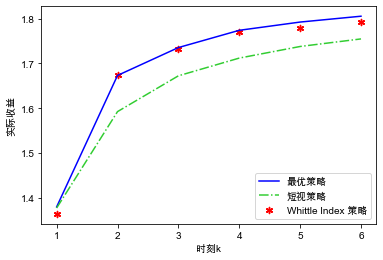

In [375]:
plt.plot(range(1, 7), y, label='最优策略', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index 策略', c='red', marker=(6,2,0))
plt.plot(range(1, 7), myopic, label='短视策略', c='limegreen', linestyle='-.')

plt.xlabel('时刻k')
plt.ylabel('实际收益')
plt.legend()

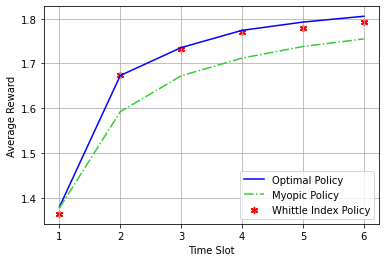

In [22]:
plt.plot(range(1, 7), y, label='Optimal Policy', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index Policy', c='red', marker=(6,2,0))
plt.plot(range(1, 7), myopic, label='Myopic Policy', c='limegreen', linestyle='-.')

plt.grid()
plt.xlabel('Time Slot')
plt.ylabel('Average Reward')
plt.legend()

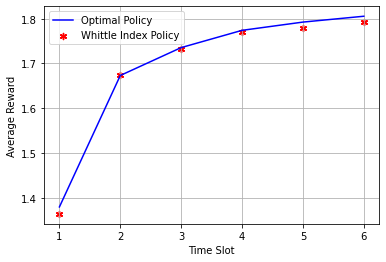

In [23]:
plt.plot(range(1, 7), y, label='Optimal Policy', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index Policy', c='red', marker=(6,2,0))
#plt.plot(range(1, 7), myopic, label='Myopic Policy', c='limegreen', linestyle='-.')

plt.grid()
plt.xlabel('Time Slot')
plt.ylabel('Average Reward')
plt.legend()

In [376]:
(whittle - myopic).sum()/6

0.04444915166666663

In [377]:
np.round(transition_matrics,3)

array([[[0.036, 0.607, 0.357],
        [0.053, 0.126, 0.821],
        [0.579, 0.359, 0.062]],

       [[0.03 , 0.171, 0.798],
        [0.678, 0.134, 0.187],
        [0.597, 0.358, 0.044]],

       [[0.358, 0.263, 0.379],
        [0.264, 0.249, 0.487],
        [0.4  , 0.364, 0.236]],

       [[0.087, 0.454, 0.459],
        [0.181, 0.672, 0.147],
        [0.462, 0.492, 0.046]],

       [[0.331, 0.181, 0.488],
        [0.347, 0.117, 0.536],
        [0.245, 0.197, 0.558]],

       [[0.323, 0.177, 0.501],
        [0.174, 0.138, 0.689],
        [0.416, 0.31 , 0.274]],

       [[0.067, 0.435, 0.499],
        [0.334, 0.29 , 0.376],
        [0.258, 0.483, 0.259]]])

In [378]:
np.round(initial_dist,3)

array([[0.284, 0.404, 0.312],
       [0.297, 0.361, 0.342],
       [0.043, 0.42 , 0.536],
       [0.642, 0.026, 0.332],
       [0.606, 0.017, 0.377],
       [0.362, 0.56 , 0.078],
       [0.296, 0.298, 0.406]])

In [379]:
np.round(reward, 3)

array([[0.   , 1.004, 2.186],
       [0.   , 1.155, 2.761],
       [0.   , 0.437, 0.782],
       [0.   , 0.568, 0.619],
       [0.   , 2.448, 2.63 ],
       [0.   , 1.327, 1.945],
       [0.   , 1.858, 2.033]])

In [24]:
reward = np.array([[0.        , 0.23315076, 2.85256786],
                     [0.        , 2.35814707, 2.632259  ],
                     [0.        , 0.37835461, 1.24064928],
                     [0.        , 2.00231981, 2.37437435],
                     [0.        , 1.502187  , 2.25841752],
                     [0.        , 0.71532548, 1.02234513],
                     [0.        , 2.01322409, 2.43634056]])
              
transition_matrics = np.array([[[0.41291509, 0.32925192, 0.25783299],
                               [0.08853962, 0.51122598, 0.4002344 ],
                               [0.08613744, 0.30875076, 0.6051118 ]],

                                   [[0.44707658, 0.02127325, 0.53165017],
                                   [0.48545226, 0.16396802, 0.35057971],
                                   [0.4609395 , 0.40904674, 0.13001376]],

                                   [[0.40708949, 0.19951157, 0.39339893],
                                   [0.43473131, 0.18044782, 0.38482087],
                                   [0.24544088, 0.46477918, 0.28977993]],

                                   [[0.59768145, 0.02819131, 0.37412725],
                                   [0.76186038, 0.10932427, 0.12881535],
                                   [0.31317074, 0.3912271 , 0.29560215]],

                                   [[0.44888325, 0.00791651, 0.54320024],
                                   [0.78167943, 0.19860907, 0.0197115 ],
                                   [0.33821506, 0.61394971, 0.04783523]],

                                   [[0.42376099, 0.44180728, 0.13443172],
                                   [0.30094984, 0.18200726, 0.5170429 ],
                                   [0.16385098, 0.36011999, 0.47602903]],

                                   [[0.61264235, 0.13616764, 0.25119001],
                                   [0.45437873, 0.38326808, 0.16235319],
                                   [0.28734827, 0.69346509, 0.01918664]]])
initial_dist = np.array([[0.48588897, 0.02829263, 0.4858184 ],
                            [0.40770558, 0.49603908, 0.09625534],
                            [0.01337472, 0.24741014, 0.73921514],
                            [0.48973774, 0.25623114, 0.25403112],
                            [0.3584154 , 0.50077504, 0.14080956],
                            [0.26215194, 0.50238191, 0.23546615],
                            [0.70656053, 0.22646564, 0.06697382]])

myopic, whittle, y = (np.array([1.42125952, 1.39649049, 1.40356558, 1.42824574, 1.44651853,
        1.45746352]),
 np.array([1.39038652, 1.48305272, 1.48907835, 1.48114437, 1.4951223 ,
       1.50048136]),
 np.array([1.42310209, 1.48426699, 1.48969551, 1.49019149, 1.49802882,
        1.50329513]))

/usr/local/lib/python3.9/site-packages/matplotlib/textpath.py:74: RuntimeWarning: Glyph 26102 missing from current font.
  font.set_text(s, 0.0, flags=LOAD_NO_HINTING)
/usr/local/lib/python3.9/site-packages/matplotlib/textpath.py:74: RuntimeWarning: Glyph 21051 missing from current font.
  font.set_text(s, 0.0, flags=LOAD_NO_HINTING)
/usr/local/lib/python3.9/site-packages/matplotlib/textpath.py:74: RuntimeWarning: Glyph 23454 missing from current font.
  font.set_text(s, 0.0, flags=LOAD_NO_HINTING)
/usr/local/lib/python3.9/site-packages/matplotlib/textpath.py:74: RuntimeWarning: Glyph 38469 missing from current font.
  font.set_text(s, 0.0, flags=LOAD_NO_HINTING)
/usr/local/lib/python3.9/site-packages/matplotlib/textpath.py:74: RuntimeWarning: Glyph 25910 missing from current font.
  font.set_text(s, 0.0, flags=LOAD_NO_HINTING)
/usr/local/lib/python3.9/site-packages/matplotlib/textpath.py:74: RuntimeWarning: Glyph 30410 missing from current font.
  font.set_text(s, 0.0, flags=LOAD_NO_H

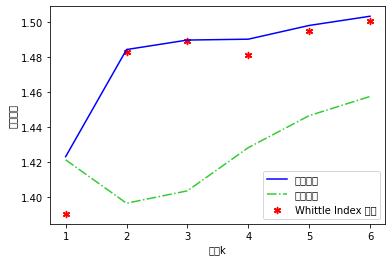

In [22]:
plt.plot(range(1, 7), y, label='最优策略', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index 策略', c='red', marker=(6,2,0))
plt.plot(range(1, 7), myopic, label='短视策略', c='limegreen', linestyle='-.')

plt.xlabel('时刻k')
plt.ylabel('实际收益')
plt.legend()

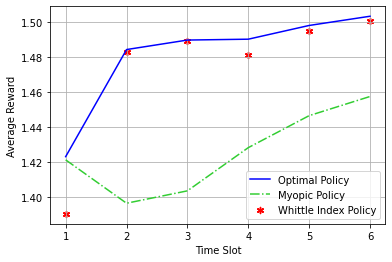

In [25]:
plt.plot(range(1, 7), y, label='Optimal Policy', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index Policy', c='red', marker=(6,2,0))
plt.plot(range(1, 7), myopic, label='Myopic Policy', c='limegreen', linestyle='-.')

plt.grid()
plt.xlabel('Time Slot')
plt.ylabel('Average Reward')
plt.legend()

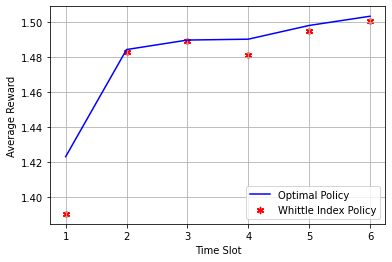

In [26]:
plt.plot(range(1, 7), y, label='Optimal Policy', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index Policy', c='red', marker=(6,2,0))
#plt.plot(range(1, 7), myopic, label='Myopic Policy', c='limegreen', linestyle='-.')

plt.grid()
plt.xlabel('Time Slot')
plt.ylabel('Average Reward')
plt.legend()

In [323]:
(whittle - myopic).sum()/6

0.04762037333333339

In [324]:
np.round(transition_matrics,3)

array([[[0.413, 0.329, 0.258],
        [0.089, 0.511, 0.4  ],
        [0.086, 0.309, 0.605]],

       [[0.447, 0.021, 0.532],
        [0.485, 0.164, 0.351],
        [0.461, 0.409, 0.13 ]],

       [[0.407, 0.2  , 0.393],
        [0.435, 0.18 , 0.385],
        [0.245, 0.465, 0.29 ]],

       [[0.598, 0.028, 0.374],
        [0.762, 0.109, 0.129],
        [0.313, 0.391, 0.296]],

       [[0.449, 0.008, 0.543],
        [0.782, 0.199, 0.02 ],
        [0.338, 0.614, 0.048]],

       [[0.424, 0.442, 0.134],
        [0.301, 0.182, 0.517],
        [0.164, 0.36 , 0.476]],

       [[0.613, 0.136, 0.251],
        [0.454, 0.383, 0.162],
        [0.287, 0.693, 0.019]]])

In [325]:
np.round(initial_dist, 3)

array([[0.486, 0.028, 0.486],
       [0.408, 0.496, 0.096],
       [0.013, 0.247, 0.739],
       [0.49 , 0.256, 0.254],
       [0.358, 0.501, 0.141],
       [0.262, 0.502, 0.235],
       [0.707, 0.226, 0.067]])

In [326]:
np.round(reward, 3)

array([[0.   , 0.233, 2.853],
       [0.   , 2.358, 2.632],
       [0.   , 0.378, 1.241],
       [0.   , 2.002, 2.374],
       [0.   , 1.502, 2.258],
       [0.   , 0.715, 1.022],
       [0.   , 2.013, 2.436]])